# Fitness ML Tracker — End-to-End Pipeline

This notebook walks through the full workflow behind the project, from raw fitness
telemetry to a next-week body-weight forecast:

```
Raw telemetry -> cleaning -> feature engineering -> EDA -> model training -> inference
```

It mirrors the production scripts (`scripts/build_features.py`, `model/train_model.py`)
so every step is reproducible and inspectable in one place.

**Prediction task:** forecast the 7-day smoothed body weight one week ahead from
today's rolling calorie balance and rolling weight.

## 1. Setup

Imports, project paths, and a consistent chart style. The notebook is expected to run
from the `notebooks/` directory of the repository.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Resolve the project root whether we run from notebooks/ or the repo root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "model"
sys.path.append(str(MODEL_DIR))  # for predictors.CurrentWeightBaselineRegressor

from predictors import CurrentWeightBaselineRegressor

# --- Chart style: recessive chrome, ink for text, color reserved for data series ---
COLORS = {
    "series1": "#2a78d6",  # blue   - primary series (weight)
    "series2": "#eb6834",  # orange - secondary series (calories / model)
    "series3": "#1baf7a",  # aqua   - tertiary series (baseline)
    "muted":   "#898781",  # raw/noise layers, tick labels
    "grid":    "#e1e0d9",
    "axis":    "#c3c2b7",
    "ink":     "#0b0b0b",
    "ink2":    "#52514e",
}
plt.rcParams.update({
    "figure.figsize": (9, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": COLORS["axis"],
    "axes.labelcolor": COLORS["ink2"],
    "axes.titlecolor": COLORS["ink"],
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.8,
    "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"],
    "font.family": "sans-serif",
})

print(f"Project root: {PROJECT_ROOT.name}")

Project root: Smart calories tracker


## 2. Load raw telemetry

Daily health telemetry exported from a fitness tracker and nutrition log: body weight,
calorie intake, macros, steps, and energy expenditure. Real-world logging is messy —
weight is not recorded every day and nutrition logging has gaps — so missingness is
part of the problem, not an inconvenience.

In [2]:
df = pd.read_csv(DATA_RAW / "health_wide_full.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)  # chronological order is required downstream

print(f"Rows: {len(df)}   Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
df.head()

Rows: 91   Date range: 2026-01-30 -> 2026-06-02


,Date,Body Weight,Calories,Protein,Active Energy,Basal Energy,Steps,Carbs,Fat
0,2026-01-30,90.0,NaN,NaN,1336.110,2100.62,8281.81,NaN,NaN
1,2026-01-31,90.0,NaN,NaN,172.781,1954.23,2057.00,NaN,NaN
2,2026-02-01,90.0,1671.93,146.038,838.449,2032.00,10727.00,NaN,NaN
3,2026-02-02,90.0,1833.31,139.520,1579.560,2101.10,11599.00,NaN,NaN
4,2026-02-03,90.0,1643.23,143.348,1187.650,2106.63,13067.00,NaN,NaN


In [3]:
# How incomplete is the raw log?
missing = df.isna().sum().to_frame("missing_rows")
missing["missing_pct"] = (missing["missing_rows"] / len(df) * 100).round(1)
missing[missing["missing_rows"] > 0]

,missing_rows,missing_pct
Calories,54,59.3
Protein,54,59.3
Active Energy,4,4.4
Basal Energy,4,4.4
Steps,1,1.1
Carbs,90,98.9
Fat,90,98.9


## 3. Cleaning & imputation

Two different strategies, chosen per signal:

- **Tracker energy signals** (`Basal Energy`, `Active Energy`) are continuous physical
  quantities, so gaps are filled with **linear interpolation**.
- **Logged calories** are behavioral (a missing day usually means "didn't log"), so we
  impute with the **median** intake rather than inventing a trend.

In [4]:
df["Basal Energy"] = df["Basal Energy"].interpolate(method="linear")
df["Active Energy"] = df["Active Energy"].interpolate(method="linear")
df["Calories_Imputed"] = df["Calories"].fillna(df["Calories"].median())

remaining = df[["Basal Energy", "Active Energy", "Calories_Imputed"]].isna().sum()
print("Remaining missing values after cleaning:")
print(remaining.to_string())

Remaining missing values after cleaning:
Basal Energy        0
Active Energy       0
Calories_Imputed    0


## 4. Feature engineering

Three ideas turn cleaned telemetry into model-ready features:

1. **Thermodynamics as features** — energy balance is engineered explicitly:
   `Tracker_TDEE = Basal + Active`, `Net_Calorie_Balance = Intake - TDEE`.
2. **Signal smoothing** — 7-day rolling means remove day-to-day water/glycogen noise
   from both weight and calorie balance.
3. **Look-ahead target alignment** — the future 7-day smoothed weight is shifted back
   7 days so each row pairs *today's* features with *next week's* outcome.

In [5]:
# 1) Energy balance
df["Tracker_TDEE"] = df["Basal Energy"] + df["Active Energy"]
df["Net_Calorie_Balance"] = df["Calories_Imputed"] - df["Tracker_TDEE"]

# 2) 7-day smoothing (min_periods=1 keeps the first week usable)
df["Weight_7Day_Avg"] = df["Body Weight"].rolling(window=7, min_periods=1).mean()
df["Net_Calorie_7Day_Avg"] = df["Net_Calorie_Balance"].rolling(window=7, min_periods=1).mean()

# 3) Look-ahead targets
df["Target_Weight_Next_Week"] = df["Weight_7Day_Avg"].shift(-7)
df["Target_Weight_Class_Next_Week"] = (
    df["Target_Weight_Next_Week"] > df["Weight_7Day_Avg"]
).astype(int)

df[["Date", "Net_Calorie_7Day_Avg", "Weight_7Day_Avg",
    "Target_Weight_Next_Week", "Target_Weight_Class_Next_Week"]].head(10)

,Date,Net_Calorie_7Day_Avg,Weight_7Day_Avg,Target_Weight_Next_Week,Target_Weight_Class_Next_Week
0,2026-01-30,-1626.690000,90.0,90.0,0
1,2026-01-31,-971.830500,90.0,90.0,0
2,2026-02-01,-1047.393333,90.0,90.0,0
3,2026-02-02,-1247.382500,90.0,90.0,0
4,2026-02-03,-1328.116000,90.0,90.0,0
5,2026-02-04,-1449.713333,90.0,90.0,0
6,2026-02-05,-1309.334000,90.0,90.0,0
7,2026-02-06,-1319.884000,90.0,90.0,0
8,2026-02-07,-1331.324286,90.0,90.0,0
9,2026-02-08,-1408.087286,90.0,90.0,0


## 5. Exploratory charts

### Body weight: raw signal vs 7-day smoothing

The daily scale readings jump around with hydration and glycogen; the rolling average
is the trend the model should care about.

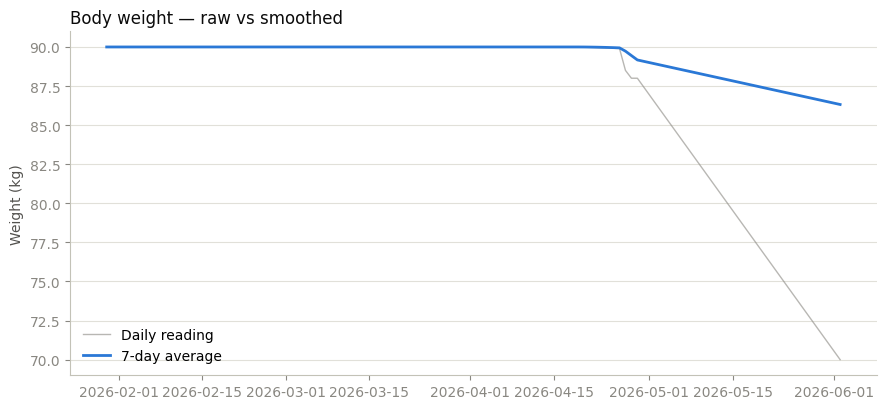

In [6]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["Body Weight"], color=COLORS["muted"], linewidth=1,
        alpha=0.6, label="Daily reading")
ax.plot(df["Date"], df["Weight_7Day_Avg"], color=COLORS["series1"], linewidth=2,
        label="7-day average")
ax.set_title("Body weight — raw vs smoothed")
ax.set_ylabel("Weight (kg)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Net calorie balance

Positive = surplus (eating above expenditure), negative = deficit. This is the main
driver signal the model sees.

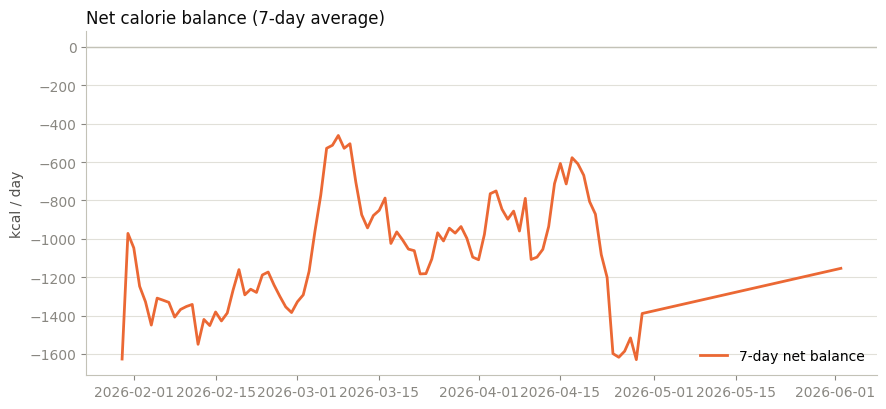

In [7]:
fig, ax = plt.subplots()
ax.axhline(0, color=COLORS["axis"], linewidth=1)
ax.plot(df["Date"], df["Net_Calorie_7Day_Avg"], color=COLORS["series2"], linewidth=2,
        label="7-day net balance")
ax.set_title("Net calorie balance (7-day average)")
ax.set_ylabel("kcal / day")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Modeling

**Setup:**

- Features: `Net_Calorie_7Day_Avg`, `Weight_7Day_Avg`
- Target: `Target_Weight_Next_Week`
- **Chronological 80/20 split, no shuffle** — shuffling a time series leaks future
  information into training and produces flattering but meaningless scores.

Two candidates are compared honestly:

1. A **regularized XGBoost regressor** (shallow trees, heavy L1/L2, strong
   `min_child_weight`) — deliberately constrained because the dataset is small.
2. A **naive baseline** that predicts next week's smoothed weight = today's smoothed
   weight. Any model worth deploying must beat this.

In [8]:
FEATURES = ["Net_Calorie_7Day_Avg", "Weight_7Day_Avg"]
TARGET = "Target_Weight_Next_Week"

model_df = df.dropna(subset=[TARGET, *FEATURES]).reset_index(drop=True)
X, y = model_df[FEATURES], model_df[TARGET]

split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test = model_df["Date"].iloc[split:]

print(f"Train rows: {len(X_train)}   Test rows: {len(X_test)}")

xgb_model = XGBRegressor(
    n_estimators=20, learning_rate=0.03, max_depth=1, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=20.0,
    random_state=42, objective="reg:squarederror",
)
baseline_model = CurrentWeightBaselineRegressor()

xgb_model.fit(X_train, y_train)
baseline_model.fit(X_train, y_train);

Train rows: 67   Test rows: 17


In [9]:
def regression_metrics(y_true, preds):
    errors = np.abs(preds - y_true)
    return {
        "MAE (kg)": mean_absolute_error(y_true, preds),
        "RMSE (kg)": mean_squared_error(y_true, preds) ** 0.5,
        "R2": r2_score(y_true, preds),
        "within ±0.5 kg (%)": (errors <= 0.5).mean() * 100,
        "within ±1.0 kg (%)": (errors <= 1.0).mean() * 100,
    }

preds = {
    "XGBoost (train)": (y_train, xgb_model.predict(X_train)),
    "XGBoost (test)": (y_test, xgb_model.predict(X_test)),
    "Baseline (train)": (y_train, baseline_model.predict(X_train)),
    "Baseline (test)": (y_test, baseline_model.predict(X_test)),
}
scores = pd.DataFrame({name: regression_metrics(t, p) for name, (t, p) in preds.items()}).T
scores.round(4)

,MAE (kg),RMSE (kg),R2,within ±0.5 kg (%),within ±1.0 kg (%)
XGBoost (train),0.0000,0.0000,1.0000,100.0000,100.0000
XGBoost (test),0.3236,0.9271,-0.1387,82.3529,94.1176
Baseline (train),0.0000,0.0000,1.0000,100.0000,100.0000
Baseline (test),0.3212,0.9214,-0.1249,82.3529,94.1176


### Model selection

The selection rule is simple and honest: **keep XGBoost only if it beats the baseline
on the chronological holdout**. With ~80 rows of fairly flat history, a flexible model
mostly memorizes the training period — the train-vs-test MAE gap above shows exactly
that risk. When the baseline wins, the baseline ships.

In [10]:
xgb_mae = scores.loc["XGBoost (test)", "MAE (kg)"]
base_mae = scores.loc["Baseline (test)", "MAE (kg)"]

if xgb_mae < base_mae:
    selected_name, selected_model = "Regularized XGBoost regressor", xgb_model
else:
    selected_name, selected_model = "Current 7-day weight baseline", baseline_model

print(f"XGBoost holdout MAE : {xgb_mae:.4f} kg")
print(f"Baseline holdout MAE: {base_mae:.4f} kg")
print(f"\nSelected model: {selected_name}")

results = X_test.copy()
results.insert(0, "Date", dates_test.dt.date.values)
results["Actual"] = y_test.values
results["Predicted"] = selected_model.predict(X_test)
results["Abs_Error"] = (results["Predicted"] - results["Actual"]).abs()
results.round(3)

XGBoost holdout MAE : 0.3236 kg
Baseline holdout MAE: 0.3212 kg

Selected model: Current 7-day weight baseline


,Date,Net_Calorie_7Day_Avg,Weight_7Day_Avg,Actual,Predicted,Abs_Error
67,2026-04-07,-855.670,90.000,90.000,90.000,0.000
68,2026-04-08,-959.467,90.000,90.000,90.000,0.000
69,2026-04-09,-789.136,90.000,90.000,90.000,0.000
70,2026-04-10,-1107.505,90.000,90.000,90.000,0.000
71,2026-04-11,-1095.703,90.000,90.000,90.000,0.000
72,2026-04-12,-1054.804,90.000,90.000,90.000,0.000
73,2026-04-13,-935.892,90.000,89.998,90.000,0.002
74,2026-04-14,-712.138,90.000,89.994,90.000,0.006
75,2026-04-15,-607.402,90.000,89.988,90.000,0.012
76,2026-04-16,-714.028,90.000,89.980,90.000,0.020


### Holdout: predicted vs actual

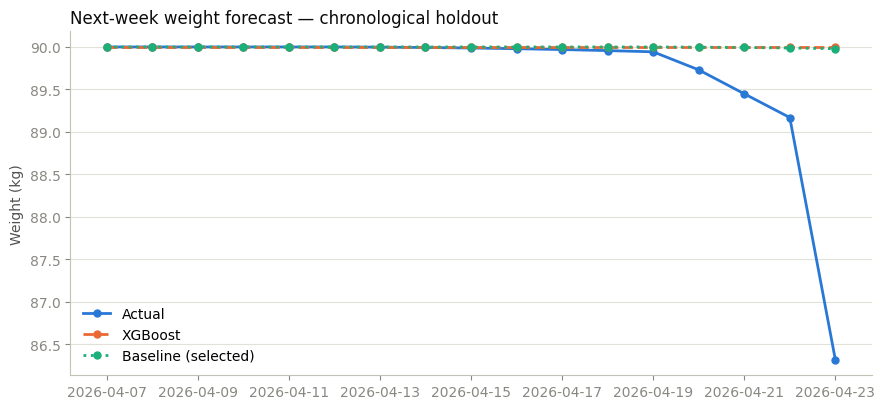

In [11]:
fig, ax = plt.subplots()
ax.plot(dates_test, y_test, color=COLORS["series1"], linewidth=2,
        marker="o", markersize=5, label="Actual")
ax.plot(dates_test, xgb_model.predict(X_test), color=COLORS["series2"], linewidth=2,
        linestyle="--", marker="o", markersize=5, label="XGBoost")
ax.plot(dates_test, baseline_model.predict(X_test), color=COLORS["series3"], linewidth=2,
        linestyle=":", marker="o", markersize=5, label="Baseline (selected)")
ax.set_title("Next-week weight forecast — chronological holdout")
ax.set_ylabel("Weight (kg)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Inference with the saved artifact

The dashboard (`src/app.py`) loads `model/weight_predictor.joblib` and forecasts from
the most recent row of features — reproduced here. (The artifact itself is produced by
`model/train_model.py`; this notebook does not overwrite it.)

In [12]:
artifact = joblib.load(MODEL_DIR / "weight_predictor.joblib")

latest = model_df[FEATURES].iloc[[-1]]
forecast = float(artifact.predict(latest)[0])
current = float(latest["Weight_7Day_Avg"].iloc[0])

print(f"Loaded artifact        : {type(artifact).__name__}")
print(f"Current 7-day weight   : {current:.2f} kg")
print(f"Forecast (next week)   : {forecast:.2f} kg")
print(f"Predicted change       : {forecast - current:+.2f} kg")

Loaded artifact        : CurrentWeightBaselineRegressor
Current 7-day weight   : 89.98 kg
Forecast (next week)   : 89.98 kg
Predicted change       : +0.00 kg


## Takeaways

- **Honest evaluation beats leaderboard chasing.** On a small, flat-trend dataset the
  naive rolling-weight baseline is genuinely hard to beat; shipping it is the
  lower-risk choice, and the pipeline re-evaluates the comparison on every retrain.
- **Time-series hygiene matters**: chronological splits, look-ahead target shifting,
  and rolling-window smoothing prevent the most common leakage mistakes.
- **Next milestones**: collect a longer and more varied weight history, add
  lag/trend-slope features, and revisit the XGBoost-vs-baseline comparison once the
  data can support a more flexible model.